# Machine Learning: Exercise session 10

In this exercise session we will learn to implement and use neural networks (NN).

The two practical problems deal with multi-layer perceptrons, also called dense NN or fully-connected feed-forward NN.

Convolutional NN will be the follow-up topic of the next exercise session.

## 1. Basics of dense neural networks

Make sure you have `tensorflow` installed on your computer. `Tensorflow` is a software geared towards Deep Learning, i.e., neural networks. It comes as a Python package, so it must be installed as you would install other packages, e.g. with

    pip install --upgrade tensorflow.
    
`Keras` is a sub-library that comes with `tensorflow` and provides a user-friendly interface to create, fit, and predict neural networks easily.

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

The goal of this problem is to build an image classifier with a dense NN. We will be using the Fashion MNIST dataset [https://github.com/zalandoresearch/fashion-mnist#readme].
Fashion-MNIST is a dataset of Zalando's article images—consisting of a training set of 60,000 examples and a test set of 10,000 examples.
The dataset consists of 10 classes which are `T-shirt/top`, `Trouser`, `Pullover`, `Dress`, `Coat`, `Sandal`, `Shirt`, `Sneaker`, `Bag`, and `Ankle boot`.

### 1.1 Importing and pre-processing the data

* Load the data by filling the `??`. Furthermore, investigate the dimension and type of the training data.

In [2]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [4]:
X_train_full[0]

9

In [5]:
print(X_train_full.shape)
print(X_train_full.dtype)

(60000, 28, 28)
uint8


* The pixel intensities are represented as integers (from 0 to 255). Since we are going to train the NN using gradient descent, we may scale the input features so that they lie in the [0, 1] interval.
Fill in the `??`.

_Hint_: Notice that you want your input features to be floats, but the original values are stored as integers.

In [6]:
X_train_scaled = X_train_full / 255.0
X_test_scaled = X_test / 255.0
X_train_scaled.dtype

dtype('float64')

* Since the dataset has no validation set, let us create one. Split the training set so that you have 5,000 observations in the validation set. Fill in the `??`.

In [8]:
X_valid = X_train_scaled[:5000] #or better: use a train-test split
X_train = X_train_scaled[5000:]
y_valid = y_train_full[:5000]
y_train = y_train_full[5000:]

X_test = X_test_scaled

* Plot the first image in the training dataset using the `plt.imshow` function. Set the argument `cmap="binary"`.

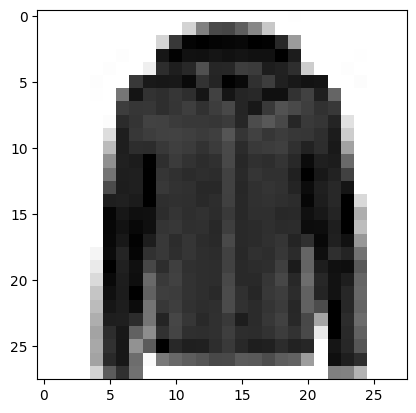

In [11]:
plt.imshow(X_train[0], cmap="binary");

* In this dataset, the classes are encoded as integers from 0 to 9. From the dataset websites, retrieve the names of the classes and store them in a list of strings. Fill in the `??`.

In [12]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", 
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [13]:
class_names[2]

'Pullover'

* Having encoded the integer classes with their names, we can now plot some images and their corresponding labels. Fill in the `??`.

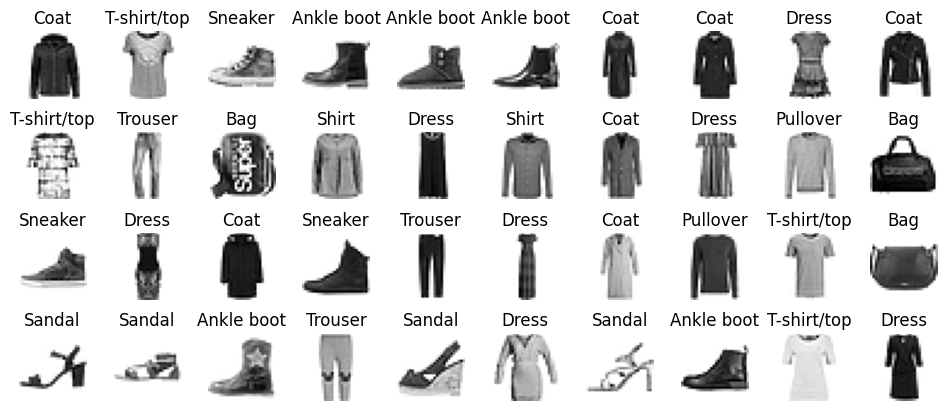

In [14]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary")
        plt.title(class_names[y_train[index]], fontsize=12)
        plt.axis('off')
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

### 1.2 Multi-layer perception (dense neural network)

* We are now ready to build the architecture for our neural network. We want two hidden layers with 300 and 100 nodes respectively and the `"relu"` activation function. For the final layer we use the `"softmax"` activation function. Why do we need to "flatten" the inputs? Fill in the `??`.

In [15]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(units=300, activation="relu"),
    keras.layers.Dense(units=100, activation="relu"),
    keras.layers.Dense(units=10,  activation="softmax")
])

* Using the `summary()` method of the object `model`, try to understand how to compute the number of parameters.

_Hint_: do not forget about the bias terms (i.e., intercept).

In [16]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 300)               235500    
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 dense_2 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [17]:
print( (784 + 1) * 300)
print( (300 + 1) * 100 ) # = (300 * 100) + 100 = weight matrix + bias vector
print( (100 + 1) * 10 )

235500
30100
1010


* Using the `get_layer` and `get_weights` methods, you can access the values of the weights of each layer. Fill in the `??`. Why do you think the weights are not initialized to zero?

In [20]:
weights, biases = model.get_layer("dense_1").get_weights()

In [61]:
# Or:
#weights, biases = model.layers[2].get_weights()

In [25]:
weights
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32)

* Now that the model is created, we must compile it. Specify as loss `"sparse_categorical_crossentropy"`, as optimizer `"sgd"`, and as metrics `"accuracy"`. Fill in the `??`.

In [28]:
model.compile(loss = "sparse_categorical_crossentropy", # as y is encoded as a vector of labels and not as a one hot matrix
              optimizer = "sgd",
              metrics = ["accuracy"])

* Now, let us train the model over 30 epochs. The stochastic gradient descent algorithm handles one mini-batch of observations at a time (e.g., 32 observations), and it goes through the whole training set. Each pass is called an _epoch_. Fill in the `??`.

In [29]:
fit_history = model.fit(x=X_train, y=y_train,
                        validation_data=(X_valid, y_valid),
                        batch_size = 64,
                        epochs=20)

Epoch 1/20
860/860 [==============================] - 9s 9ms/step - loss: 0.8816 - accuracy: 0.7223 - val_loss: 0.6319 - val_accuracy: 0.7868
Epoch 2/20
860/860 [==============================] - 7s 8ms/step - loss: 0.5550 - accuracy: 0.8125 - val_loss: 0.5169 - val_accuracy: 0.8286
Epoch 3/20
860/860 [==============================] - 8s 9ms/step - loss: 0.4951 - accuracy: 0.8292 - val_loss: 0.4871 - val_accuracy: 0.8354
Epoch 4/20
860/860 [==============================] - 7s 9ms/step - loss: 0.4644 - accuracy: 0.8385 - val_loss: 0.4927 - val_accuracy: 0.8330
Epoch 5/20
860/860 [==============================] - 8s 10ms/step - loss: 0.4423 - accuracy: 0.8452 - val_loss: 0.4589 - val_accuracy: 0.8398
Epoch 6/20
860/860 [==============================] - 8s 10ms/step - loss: 0.4255 - accuracy: 0.8521 - val_loss: 0.4362 - val_accuracy: 0.8456
Epoch 7/20
860/860 [==============================] - 8s 9ms/step - loss: 0.4120 - accuracy: 0.8560 - val_loss: 0.4317 - val_accuracy: 0.8550
Epoc

* Now that our model is trained, let us plot the learning curves. Fill in the `??`. Is there any evidence of overfitting? Why/why not?

In [32]:
#fit_history.history

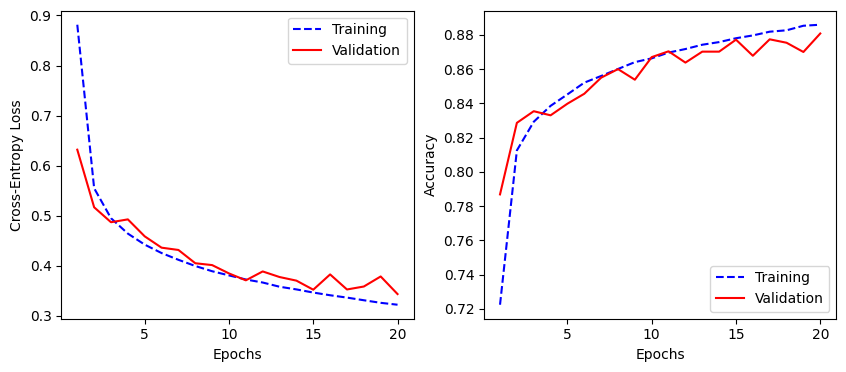

In [33]:
def plot_training(history_dict):
    acc = history_dict['accuracy']
    val_acc = history_dict['val_accuracy']
    loss = history_dict['loss']
    val_loss = history_dict['val_loss']
    
    epochs = range(1, len(loss) + 1)
    
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'b--', label='Training')
    plt.plot(epochs, val_loss, 'r-', label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Cross-Entropy Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'b--', label='Training')
    plt.plot(epochs, val_acc, 'r-', label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    
    plt.show()

plot_training(fit_history.history)

* Let us evaluate our model on the test set by calling the `evaluate()` method of the `model` object.

In [60]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 1s 4ms/step - loss: 59.8952 - accuracy: 0.8497


[59.89519500732422, 0.8496999740600586]

In [35]:
model.predict(X_valid)

157/157 [==============================] - 1s 3ms/step


array([[1.1845883e-08, 1.8153712e-09, 4.5873255e-10, ..., 6.8894471e-04,
        1.1004660e-06, 9.9922228e-01],
       [9.9675035e-01, 1.4961586e-07, 7.4670512e-05, ..., 9.8378465e-11,
        8.4548003e-07, 1.2770573e-09],
       [4.2938772e-01, 5.2665226e-02, 3.1904712e-02, ..., 1.4325602e-03,
        3.3401656e-03, 4.7723216e-04],
       ...,
       [5.5117504e-04, 1.4376367e-04, 2.0232535e-04, ..., 1.0143729e-01,
        1.6108675e-02, 6.9075599e-03],
       [4.0570274e-03, 2.4063396e-05, 5.8049336e-03, ..., 1.4464794e-07,
        9.6803635e-01, 8.3944176e-09],
       [3.9283610e-03, 3.0568032e-02, 3.0726839e-03, ..., 2.1931164e-04,
        1.2358224e-03, 7.0375594e-05]], dtype=float32)

* Let us predict the class of the observations 24, 188, 3023 in the test set and plot the results. Fill in the `??`.

In [36]:
indices = [240, 108, 423]
X_new = X_test[indices] # 3D index
y_new = y_test[indices]
y_pred = np.argmax(model.predict(X_new), axis = 1)
print("Predicted classes:", y_pred)
print("True classes:", y_new)

1/1 [==============================] - 0s 100ms/step
Predicted classes: [5 9 5]
True classes: [5 9 5]


In [37]:
model.predict(X_new)

1/1 [==============================] - 0s 48ms/step


array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]], dtype=float32)

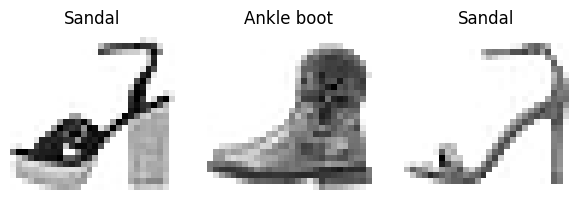

In [38]:
plt.figure(figsize=(7.2, 2.4))
for index, image in enumerate(X_new):
    cls_nm = class_names[y_new[index]]
    plt.subplot(1, 3, index + 1)
    plt.imshow(image, cmap="binary")
    plt.title(cls_nm, fontsize=12)
    plt.axis('off')
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

## 2. Controlling dense neural networks

We continue with the example of the previous problem.

#### Saving and restoring fitted models

* Since training neural networks is computationally intensive and time consuming, it is important to be able to save and restore trained models. Keras makes this very easy. Save and reload the model fitted in the previous exercise by filling in the `??`.

In [39]:
model.save("checkpoints/dense_nn.h5")

In [41]:
model_restored = keras.models.load_model("checkpoints/dense_nn.h5")

In [43]:
model_restored.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 300)               235500    
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 dense_2 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


* What if training lasts several hours? This is quite common, especially when training on large datasets. In this case, you should not only save your model at the end of training, but also save checkpoints at regular intervals during training, to avoid losing everything if your computer crashes. You can do so by using the `callbacks` argument in the `fit()` function. This argument accepts list of `callbacks`. A `callback` is an object that can perform actions at various stages of training (e.g. at the start or end of an epoch, before or after a single batch, etc) (https://keras.io/api/callbacks). Fill in the `??` to save the checkpoints of your model at the end of each epoch.

In [44]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(filepath="checkpoints/model_epoch={epoch:02d}_val_accuracy={val_accuracy:.2f}.h5")

history = model.fit(X_train, y_train, 
                    validation_data=(X_valid, y_valid),
                    batch_size = 64,
                    epochs=3, callbacks=[checkpoint_cb])
# careful: calling .fit() several times will continue the training each time

Epoch 1/3
860/860 [==============================] - 7s 9ms/step - loss: 0.3181 - accuracy: 0.8870 - val_loss: 0.3386 - val_accuracy: 0.8826
Epoch 2/3
860/860 [==============================] - 7s 8ms/step - loss: 0.3132 - accuracy: 0.8877 - val_loss: 0.3326 - val_accuracy: 0.8836
Epoch 3/3
860/860 [==============================] - 6s 7ms/step - loss: 0.3099 - accuracy: 0.8899 - val_loss: 0.3333 - val_accuracy: 0.8858


#### Avoiding overfitting

* A useful strategy to avoid overfitting with neural networks is by using early stopping, i.e., interrupt the training when there is no improvement on the validation set for a number of epochs. When this happens, early stop allows you to roll back to the best model. Notice that early stop is also implemented as a `Keras` callback. Fill in the `??`.

_Hint_: The number of epochs can be set to a large value since training will stop automatically when there is no more progress. In this case, there is no
need to restore the best model saved because the callback will keep track of the best weights and restore them for you at the end of training.

In [45]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1)

history = model.fit(X_train, y_train,
                    validation_data=(X_valid, y_valid), 
                    batch_size = 64,
                    epochs=50, callbacks=[early_stopping_cb, checkpoint_cb])

Epoch 1/50
860/860 [==============================] - 9s 10ms/step - loss: 0.3056 - accuracy: 0.8918 - val_loss: 0.3380 - val_accuracy: 0.8798
Epoch 2/50
860/860 [==============================] - 7s 8ms/step - loss: 0.3015 - accuracy: 0.8935 - val_loss: 0.3757 - val_accuracy: 0.8638
Epoch 3/50
860/860 [==============================] - 8s 9ms/step - loss: 0.2978 - accuracy: 0.8941 - val_loss: 0.3310 - val_accuracy: 0.8820
Epoch 4/50
860/860 [==============================] - 9s 10ms/step - loss: 0.2944 - accuracy: 0.8945 - val_loss: 0.3273 - val_accuracy: 0.8834
Epoch 5/50
860/860 [==============================] - 8s 9ms/step - loss: 0.2917 - accuracy: 0.8967 - val_loss: 0.3348 - val_accuracy: 0.8798
Epoch 6/50
860/860 [==============================] - 8s 9ms/step - loss: 0.2877 - accuracy: 0.8971 - val_loss: 0.3891 - val_accuracy: 0.8530
Epoch 7/50
860/860 [==============================] - 6s 7ms/step - loss: 0.2845 - accuracy: 0.8984 - val_loss: 0.3529 - val_accuracy: 0.8780
Epoc

* In neural networks there is high risk of overfitting the training data. Therefore, it is important to apply some form of regularization. A very popular one is the `dropout` which consists of dropping randomly a given percentage of nodes in some layers (during **training only**). To implement dropout using Keras, you can use the `keras.layers.Dropout` layer. Fill in the `??`.

In [57]:
model_reg = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(units=300, activation="relu"),
    keras.layers.Dense(units=100, activation="relu"),
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(units=10,  activation="softmax")
])

model_reg.compile(loss = "sparse_categorical_crossentropy",
                  optimizer = "sgd",
                  metrics = ["accuracy"])

In [48]:
history = model_reg.fit(X_train, y_train,
                        validation_data=(X_valid, y_valid), 
                        batch_size = 64,
                        epochs=10, callbacks=[early_stopping_cb, checkpoint_cb])

Epoch 1/10
860/860 [==============================] - 10s 11ms/step - loss: 0.9451 - accuracy: 0.6829 - val_loss: 0.6157 - val_accuracy: 0.8014
Epoch 2/10
860/860 [==============================] - 9s 10ms/step - loss: 0.6161 - accuracy: 0.7893 - val_loss: 0.5232 - val_accuracy: 0.8260
Epoch 3/10
860/860 [==============================] - 9s 10ms/step - loss: 0.5390 - accuracy: 0.8153 - val_loss: 0.4755 - val_accuracy: 0.8396
Epoch 4/10
860/860 [==============================] - 9s 10ms/step - loss: 0.4985 - accuracy: 0.8278 - val_loss: 0.4946 - val_accuracy: 0.8250
Epoch 5/10
860/860 [==============================] - 9s 10ms/step - loss: 0.4724 - accuracy: 0.8361 - val_loss: 0.4297 - val_accuracy: 0.8520
Epoch 6/10
860/860 [==============================] - 8s 9ms/step - loss: 0.4518 - accuracy: 0.8417 - val_loss: 0.4217 - val_accuracy: 0.8554
Epoch 7/10
860/860 [==============================] - 8s 9ms/step - loss: 0.4351 - accuracy: 0.8469 - val_loss: 0.4145 - val_accuracy: 0.8568


In [49]:
model_reg.evaluate(X_test, y_test);

313/313 [==============================] - 1s 3ms/step - loss: 59.8326 - accuracy: 0.8236


#### Learning rate and optimization

* Finding a good learning rate is very important. If you set it much too high, training may diverge (as we discussed in “Gradient Descent”). If you set it too low, training will eventually converge to an optimum, but it will take a very long time. One of the easiest options is to use a constant learning rate. Fill in the `??` by setting the learning rate to 0.01.

In [ ]:
optimizer = keras.optimizers.SGD(learning_rate=0.01)#0.01 0.001 0.8

model_reg.compile(loss = "sparse_categorical_crossentropy",
                  optimizer = optimizer,
                  metrics = ["accuracy"])

history = model_reg.fit(X_train, y_train,
                        validation_data=(X_valid, y_valid), 
                        batch_size = 64,
                        epochs=7, callbacks=[early_stopping_cb, checkpoint_cb])

* Another issue with training neural networks is the presence of local loss minima, as the optimization problem with so many weights is non-convex. The gradient descent procedure can then get "stuck" in these local minima, although better solutions might exist. On top of tuning the learning rate, adding momentum during the gradient descent steps can help avoiding those local minima. The simplest form of momentum can be achieved by setting a positive `momentum` value in `keras.optimizers.SGD`. However, more complex momentum methods for stochastic gradient descent have since then been developed, like the now very popular `Adam` moment-based stochastic gradient descent algorithm.

In [58]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)

model_reg.compile(loss = "sparse_categorical_crossentropy",
                  optimizer = optimizer,
                  metrics = ["accuracy"])

history = model_reg.fit(X_train, y_train,
                        validation_data=(X_valid, y_valid), 
                        batch_size = 64,
                        epochs=50, callbacks=[early_stopping_cb, checkpoint_cb])

Epoch 1/50
860/860 [==============================] - 9s 10ms/step - loss: 0.5286 - accuracy: 0.8120 - val_loss: 0.3879 - val_accuracy: 0.8620
Epoch 2/50
860/860 [==============================] - 7s 9ms/step - loss: 0.3889 - accuracy: 0.8569 - val_loss: 0.3445 - val_accuracy: 0.8798
Epoch 3/50
860/860 [==============================] - 9s 11ms/step - loss: 0.3457 - accuracy: 0.8728 - val_loss: 0.3318 - val_accuracy: 0.8788
Epoch 4/50
860/860 [==============================] - 9s 10ms/step - loss: 0.3240 - accuracy: 0.8803 - val_loss: 0.3216 - val_accuracy: 0.8826
Epoch 5/50
860/860 [==============================] - 9s 11ms/step - loss: 0.3038 - accuracy: 0.8884 - val_loss: 0.3090 - val_accuracy: 0.8910
Epoch 6/50
860/860 [==============================] - 8s 10ms/step - loss: 0.2877 - accuracy: 0.8931 - val_loss: 0.3227 - val_accuracy: 0.8870
Epoch 7/50
860/860 [==============================] - 9s 10ms/step - loss: 0.2778 - accuracy: 0.8967 - val_loss: 0.2958 - val_accuracy: 0.8908


In [59]:
model_reg.evaluate(X_test, y_test)

313/313 [==============================] - 1s 3ms/step - loss: 45.0438 - accuracy: 0.8709


[45.04384231567383, 0.8708999752998352]